TITANIC ML PIPELINE ASSIGNMENT

Dataset loaded successfully!
Dataset Shape: (891, 12)

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



EXPLORATORY DATA ANALYSIS

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


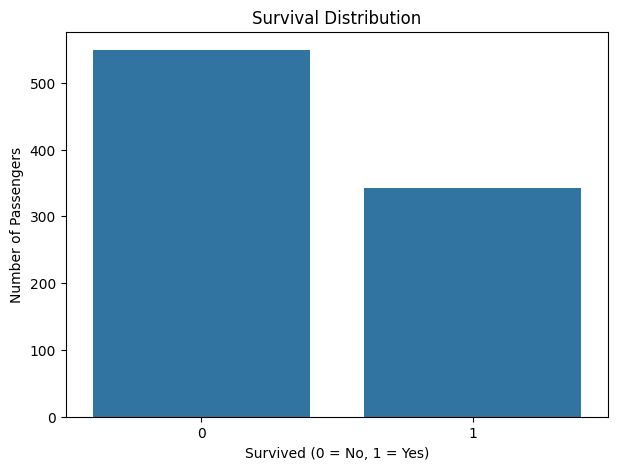

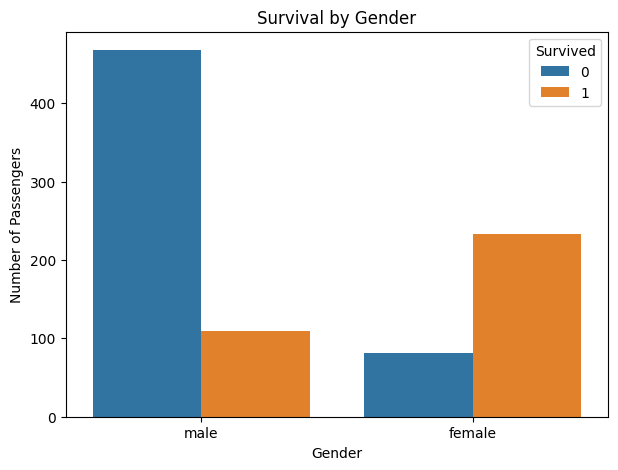

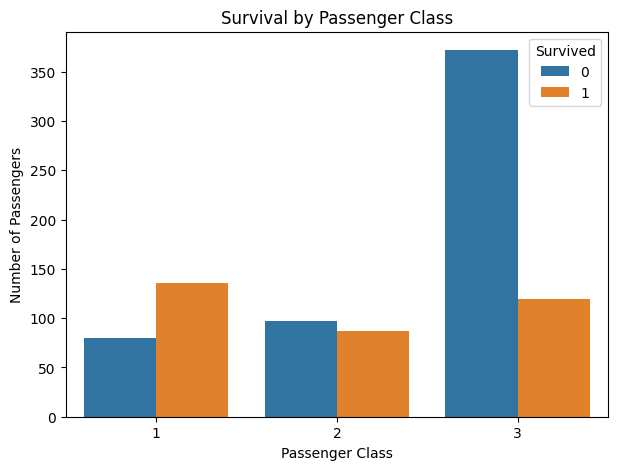

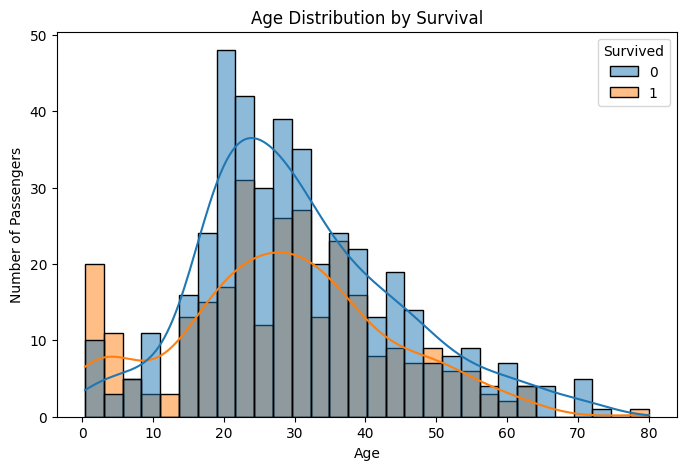


FEATURE ENGINEERING

Two new features created:
1. FamilySize = SibSp + Parch + 1
2. IsAlone = 1 if FamilySize == 1, otherwise 0

Engineered Features Preview:


,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0
5,0,0,1,1,0
6,0,0,1,1,0
7,3,1,5,0,0
8,0,2,3,0,1
9,1,0,2,0,1



Survival Rate by Family Size:
FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64

Survival Rate by IsAlone:
IsAlone
0    0.506
1    0.304
Name: Survived, dtype: float64


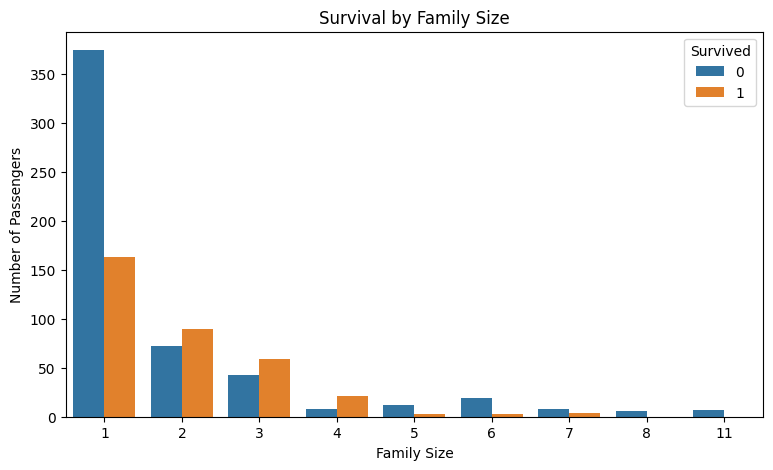

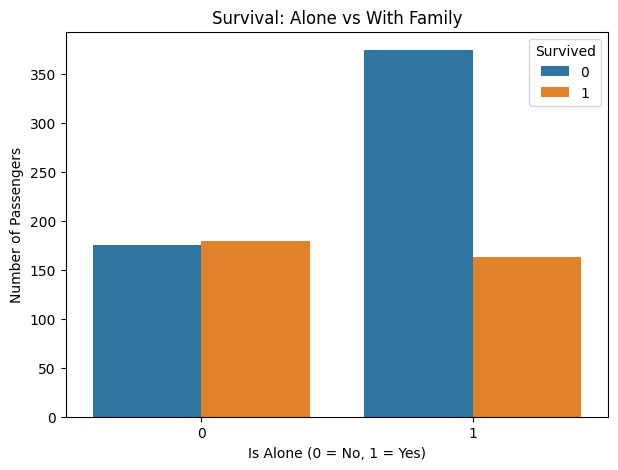


BASELINE MODEL

Baseline Performance:
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244

FINAL PIPELINE WITH FEATURE ENGINEERING

Pipeline Structure:
Raw Data
    ↓
ColumnTransformer
    ├── Numerical → Imputer → StandardScaler
    └── Categorical → Imputer → OneHotEncoder
    ↓
Logistic Regression

Final pipeline trained successfully!

FINAL PIPELINE PERFORMANCE
Accuracy : 0.8045
Precision: 0.7833
Recall   : 0.6812
F1 Score : 0.7287

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



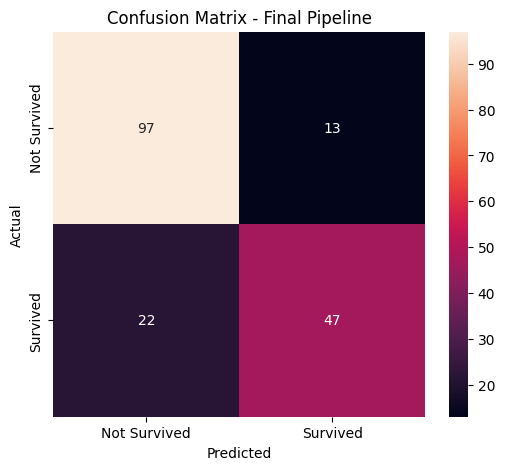


BASELINE VS FINAL PIPELINE


,Metric,Baseline,Final Pipeline,Improvement
0,Accuracy,0.8045,0.8045,0.0000
1,Precision,0.7931,0.7833,-0.0098
2,Recall,0.6667,0.6812,0.0145
3,F1 Score,0.7244,0.7287,0.0043



Feature Engineering Results:
Accuracy Change: +0.0000
F1 Score Change: +0.0043
= Feature engineering produced the same accuracy.
✓ Feature engineering improved F1 score.


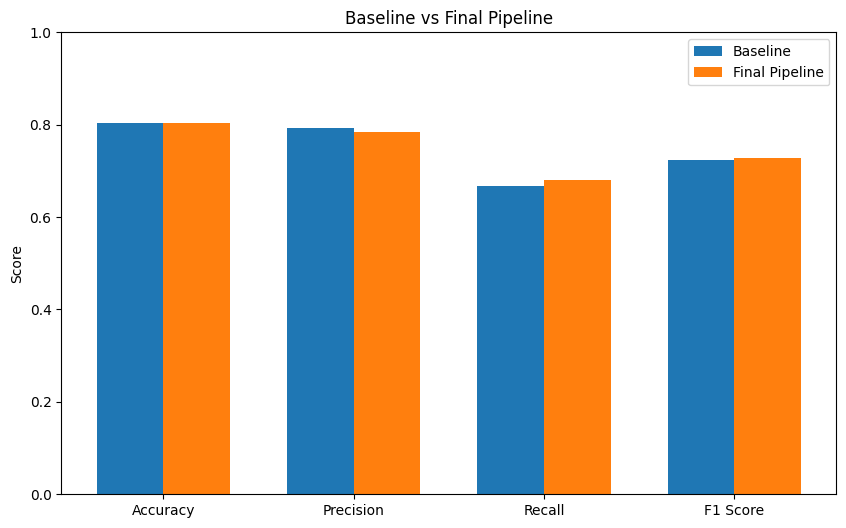


PIPELINE COMPONENTS

Complete Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                         

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("TITANIC ML PIPELINE ASSIGNMENT")
print("=" * 70)


# -----------------------------
# 2. Load Dataset
# -----------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())


# -----------------------------
# 3. Basic EDA
# -----------------------------
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)


# -----------------------------
# 4. EDA Visualizations
# -----------------------------

# Survival Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# Survival by Gender
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()


# Survival by Passenger Class
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()


# Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


# -----------------------------
# 5. Create Engineered Features
# -----------------------------
print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

df_engineered = df.copy()

# Feature 1: FamilySize
df_engineered["FamilySize"] = (
    df_engineered["SibSp"] +
    df_engineered["Parch"] +
    1
)

# Feature 2: IsAlone
df_engineered["IsAlone"] = (
    df_engineered["FamilySize"] == 1
).astype(int)

print("\nTwo new features created:")
print("1. FamilySize = SibSp + Parch + 1")
print("2. IsAlone = 1 if FamilySize == 1, otherwise 0")

print("\nEngineered Features Preview:")
display(
    df_engineered[
        ["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]
    ].head(10)
)


# -----------------------------
# 6. Analyze Engineered Features
# -----------------------------
print("\nSurvival Rate by Family Size:")
print(
    df_engineered.groupby("FamilySize")["Survived"]
    .mean()
    .round(3)
)

print("\nSurvival Rate by IsAlone:")
print(
    df_engineered.groupby("IsAlone")["Survived"]
    .mean()
    .round(3)
)


# Family Size Visualization
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_engineered,
    x="FamilySize",
    hue="Survived"
)
plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()


# IsAlone Visualization
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_engineered,
    x="IsAlone",
    hue="Survived"
)
plt.title("Survival: Alone vs With Family")
plt.xlabel("Is Alone (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# ============================================================
# 7. BASELINE MODEL
#    Original Features WITHOUT engineered features
# ============================================================

print("\n" + "=" * 70)
print("BASELINE MODEL")
print("=" * 70)

original_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X_original = df[original_features]
y_original = df["Survived"]

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

original_numerical = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

original_categorical = [
    "Sex",
    "Embarked"
]


# Baseline preprocessing
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            original_numerical
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            original_categorical
        )
    ]
)


# Baseline Pipeline
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", baseline_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# Train Baseline
baseline_pipeline.fit(
    X_train_original,
    y_train_original
)

baseline_predictions = baseline_pipeline.predict(
    X_test_original
)


# Baseline Metrics
baseline_accuracy = accuracy_score(
    y_test_original,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test_original,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test_original,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test_original,
    baseline_predictions
)

print("\nBaseline Performance:")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")


# ============================================================
# 8. FINAL PIPELINE WITH ENGINEERED FEATURES
# ============================================================

print("\n" + "=" * 70)
print("FINAL PIPELINE WITH FEATURE ENGINEERING")
print("=" * 70)


# Features including engineered features
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = df_engineered[features]
y = df_engineered["Survived"]


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Numerical columns
numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]


# Categorical columns
categorical_features = [
    "Sex",
    "Embarked"
]


# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# Complete ML Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


print("\nPipeline Structure:")
print("Raw Data")
print("    ↓")
print("ColumnTransformer")
print("    ├── Numerical → Imputer → StandardScaler")
print("    └── Categorical → Imputer → OneHotEncoder")
print("    ↓")
print("Logistic Regression")


# -----------------------------
# 9. Train Final Pipeline
# -----------------------------
pipeline.fit(X_train, y_train)

print("\nFinal pipeline trained successfully!")


# -----------------------------
# 10. Make Predictions
# -----------------------------
y_pred = pipeline.predict(X_test)


# -----------------------------
# 11. Evaluate Final Pipeline
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 70)
print("FINAL PIPELINE PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Survived", "Survived"]
    )
)


# -----------------------------
# 12. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix - Final Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 13. Compare Baseline vs Final Pipeline
# ============================================================

print("\n" + "=" * 70)
print("BASELINE VS FINAL PIPELINE")
print("=" * 70)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Final Pipeline": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison["Improvement"] = (
    comparison["Final Pipeline"] -
    comparison["Baseline"]
)

display(comparison.round(4))


# -----------------------------
# 14. Feature Engineering Result
# -----------------------------
accuracy_difference = accuracy - baseline_accuracy
f1_difference = f1 - baseline_f1

print("\nFeature Engineering Results:")

print(f"Accuracy Change: {accuracy_difference:+.4f}")
print(f"F1 Score Change: {f1_difference:+.4f}")

if accuracy_difference > 0:
    print("✓ Feature engineering improved accuracy.")
elif accuracy_difference < 0:
    print("✗ Feature engineering decreased accuracy.")
else:
    print("= Feature engineering produced the same accuracy.")

if f1_difference > 0:
    print("✓ Feature engineering improved F1 score.")
elif f1_difference < 0:
    print("✗ Feature engineering decreased F1 score.")
else:
    print("= Feature engineering produced the same F1 score.")


# -----------------------------
# 15. Visual Model Comparison
# -----------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

baseline_scores = [
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1
]

pipeline_scores = [
    accuracy,
    precision,
    recall,
    f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    baseline_scores,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    pipeline_scores,
    width,
    label="Final Pipeline"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Baseline vs Final Pipeline")
plt.ylim(0, 1)
plt.legend()

plt.show()


# ============================================================
# 16. Display Pipeline Components
# ============================================================

print("\n" + "=" * 70)
print("PIPELINE COMPONENTS")
print("=" * 70)

print("\nComplete Pipeline:")
print(pipeline)

print("\nPipeline Steps:")
for name, step in pipeline.named_steps.items():
    print(f"- {name}: {type(step).__name__}")


# ============================================================
# 17. Save Final Pipeline using Joblib
# ============================================================

print("\n" + "=" * 70)
print("SAVING FINAL PIPELINE")
print("=" * 70)

pipeline_filename = "titanic_final_pipeline.pkl"

joblib.dump(
    pipeline,
    pipeline_filename
)

print(f"✓ Pipeline saved successfully as: {pipeline_filename}")


# ============================================================
# 18. Load Saved Pipeline and Verify It
# ============================================================

loaded_pipeline = joblib.load(
    pipeline_filename
)

loaded_predictions = loaded_pipeline.predict(X_test)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print("\nLoaded Pipeline Accuracy:", f"{loaded_accuracy:.4f}")

if np.array_equal(y_pred, loaded_predictions):
    print("✓ SUCCESS: Loaded pipeline produces the same predictions.")
else:
    print("✗ Loaded pipeline predictions are different.")


# ============================================================
# 19. Test Pipeline on a New Passenger
# ============================================================

new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["male"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": ["S"]
})

# Create the same engineered features
new_passenger["FamilySize"] = (
    new_passenger["SibSp"] +
    new_passenger["Parch"] +
    1
)

new_passenger["IsAlone"] = (
    new_passenger["FamilySize"] == 1
).astype(int)


new_prediction = loaded_pipeline.predict(
    new_passenger
)

new_probability = loaded_pipeline.predict_proba(
    new_passenger
)[0]


print("\n" + "=" * 70)
print("NEW PASSENGER PREDICTION")
print("=" * 70)

if new_prediction[0] == 1:
    print("Prediction: SURVIVED")
else:
    print("Prediction: DID NOT SURVIVE")

print(f"Probability of Not Surviving: {new_probability[0]:.2%}")
print(f"Probability of Surviving:     {new_probability[1]:.2%}")


# ============================================================
# 20. Final Summary
# ============================================================

print("\n" + "=" * 70)
print("FINAL ASSIGNMENT SUMMARY")
print("=" * 70)

print("""
Dataset:
Titanic Dataset

Model:
Logistic Regression

Preprocessing:
Numerical Features → SimpleImputer → StandardScaler
Categorical Features → SimpleImputer → OneHotEncoder

Engineered Features:
1. FamilySize = SibSp + Parch + 1
2. IsAlone = 1 if FamilySize == 1, otherwise 0

Pipeline:
ColumnTransformer → Logistic Regression

Final Metrics:
""")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nBaseline Accuracy:", f"{baseline_accuracy:.4f}")
print("Final Accuracy:   ", f"{accuracy:.4f}")

print("\nSaved Model:")
print(pipeline_filename)

print("\n" + "=" * 70)
print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("=" * 70)

I built an end-to-end scikit-learn Pipeline using ColumnTransformer to preprocess numerical and categorical features consistently. Numerical features were imputed and standardized using StandardScaler, while categorical features were imputed and encoded using OneHotEncoder. I also engineered two new features, FamilySize and IsAlone, and compared their performance against a baseline model. The final pipeline was evaluated using accuracy, precision, recall, and F1-score and saved using joblib. Using a pipeline helps prevent preprocessing inconsistencies and reduces the risk of data leakage because the preprocessing and model are fitted together only on the training data.